In [1]:
import leidenalg
import argparse
import re
import time
import numpy as np
import pandas as pd
import igraph as ig
import leidenalg as la
import os
from collections import defaultdict
import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed
from datetime import datetime
from glob import glob

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
# Parameters for louivan community detection

# Gamma controls the resolution of communities
#  (higher values lead to smaller communities).
GAMMA = 1

# Omega controls the coupling between layers in the multilayer graph.
# (higher values lead to more consistent communities across layers).
OMEGA= 0.5

### Retrieve all windows from DTA_anes folder

In [ ]:
# Use the first preprocessing folder inside Bf_DTA_anes.
preprocessing_folders = sorted(glob("../outputs/window_connectivity/Bf_DTA_anes/*"))
if not preprocessing_folders:
    raise FileNotFoundError("No preprocessing folder found inside ../outputs/window_connectivity/Bf_DTA_anes")

dta_anes_folder = preprocessing_folders[0]
date_folders = sorted(
    path for path in glob(os.path.join(dta_anes_folder, "sub-*"))
    if os.path.isdir(path)
)

[os.path.basename(path) for path in date_folders]

### Group files in nested directories

Example: 

```
dta_anes_mice["sub-ag230920"]["sub-ag230920a"]
```

With the first key being the date of acquisition and the second index being the mouse itself with consequent full list of windows created

In [ ]:
def get_mouse_name(csv_path):
    """Return the mouse ID encoded by the letter after the acquisition date."""
    filename = os.path.basename(csv_path)
    match = re.match(r"^(sub-[A-Za-z]+\d+)([A-Za-z])_", filename)
    if match is None:
        raise ValueError(f"Cannot retrieve mouse name from: {filename}")
    return f"{match.group(1)}{match.group(2).lower()}"


# date folder -> mouse name -> sorted list of CSV windows
dta_anes_mice = defaultdict(lambda: defaultdict(list))

# Iterate over date folders and collect CSV paths for each mouse.
for date_folder in date_folders:

    # Extract the date name from the folder path.
    date_name = os.path.basename(date_folder)
    # Each date folder contains one subject_id subfolder per mouse run.
    csv_windows = sorted(glob(os.path.join(date_folder, "*", "*.csv")))

    # Group CSV paths by mouse name within the current date folder.
    for csv_path in csv_windows:
        mouse_name = get_mouse_name(csv_path)
        dta_anes_mice[date_name][mouse_name].append(csv_path)

{date: sorted(mice) for date, mice in dta_anes_mice.items()}

In [5]:
# Loop over the dates
for date_name in sorted(dta_anes_mice.keys()):
    print(f"Date: {date_name}")

    # Loop over mice for the current date
    for mouse_name in sorted(dta_anes_mice[date_name].keys()):
        print(f"  Mouse: {mouse_name}")

        # Loop over the first 3 CSV paths for the current mouse 
        for csv_path in dta_anes_mice[date_name][mouse_name][:3]:
            print(f"    CSV: {os.path.basename(csv_path)}")

Date: sub-ag230908
  Mouse: sub-ag230908a
    CSV: sub-ag230908a_EXP_bold_parcellated_window_0008.csv
    CSV: sub-ag230908a_EXP_bold_parcellated_window_0009.csv
    CSV: sub-ag230908a_EXP_bold_parcellated_window_0010.csv
Date: sub-ag230911
  Mouse: sub-ag230911a
    CSV: sub-ag230911a_SHAM_bold_parcellated_window_0008.csv
    CSV: sub-ag230911a_SHAM_bold_parcellated_window_0009.csv
    CSV: sub-ag230911a_SHAM_bold_parcellated_window_0010.csv
  Mouse: sub-ag230911b
    CSV: sub-ag230911b_EXP__bold_parcellated_window_0008.csv
    CSV: sub-ag230911b_EXP__bold_parcellated_window_0009.csv
    CSV: sub-ag230911b_EXP__bold_parcellated_window_0010.csv
  Mouse: sub-ag230911c
    CSV: sub-ag230911c_EXP_bold_parcellated_window_0008.csv
    CSV: sub-ag230911c_EXP_bold_parcellated_window_0009.csv
    CSV: sub-ag230911c_EXP_bold_parcellated_window_0010.csv
  Mouse: sub-ag230911d
    CSV: sub-ag230911d_SHAM_bold_parcellated_window_0008.csv
    CSV: sub-ag230911d_SHAM_bold_parcellated_window_0009.csv

In [6]:
# Test with the first CSV file of the first mouse of the first date.
first_date = sorted(dta_anes_mice.keys())[0]
first_mouse = sorted(dta_anes_mice[first_date].keys())[0]
first_csv_path = dta_anes_mice[first_date][first_mouse][0]

df = pd.read_csv(first_csv_path, index_col=0)
df

,DMNa,DMNp,SAL,OLF,STR,AUD,VIS,TH,MOp,SSp,SSs,HCa,SUB,CTXsp,BF,HY
DMNa,0.000000,0.004721,0.379607,-0.194579,-0.019047,0.483383,0.383892,0.196945,0.680299,0.454297,0.769414,0.317568,-0.026853,0.089383,-0.303671,-0.163871
DMNp,0.004721,0.000000,0.637167,0.777030,0.204129,0.458012,0.516440,-0.031291,0.554808,0.015754,0.320481,0.335584,-0.041481,0.359980,0.758096,-0.223435
SAL,0.379607,0.637167,0.000000,0.778786,0.010832,0.327639,0.180095,-0.191064,0.484445,0.342343,0.442319,0.211010,-0.404338,0.679113,0.502664,0.070916
OLF,-0.194579,0.777030,0.778786,0.000000,0.056842,0.087298,0.031212,-0.348105,0.239192,0.118674,0.057228,0.056386,-0.385894,0.667894,0.768750,0.031009
STR,-0.019047,0.204129,0.010832,0.056842,0.000000,0.585917,0.473615,0.729295,0.081687,0.684140,0.443356,0.782149,0.426405,0.287083,0.494826,-0.373407
AUD,0.483383,0.458012,0.327639,0.087298,0.585917,0.000000,0.887542,0.792187,0.386612,0.445256,0.889834,0.943696,0.604412,0.378033,0.170568,-0.694894
VIS,0.383892,0.516440,0.180095,0.031212,0.473615,0.887542,0.000000,0.690907,0.500715,0.195699,0.687653,0.824795,0.722165,0.113508,0.119314,-0.506981
TH,0.196945,-0.031291,-0.191064,-0.348105,0.729295,0.792187,0.690907,0.000000,-0.074995,0.404760,0.596705,0.891246,0.826912,0.088412,-0.055670,-0.599678
MOp,0.680299,0.554808,0.484445,0.239192,0.081687,0.386612,0.500715,-0.074995,0.000000,0.308923,0.550559,0.219419,-0.158732,0.040540,0.248583,-0.027326
SSp,0.454297,0.015754,0.342343,0.118674,0.684140,0.445256,0.195699,0.404760,0.308923,0.000000,0.636130,0.571258,-0.023971,0.555006,0.269896,-0.245507


### Visualize one connectivity graph

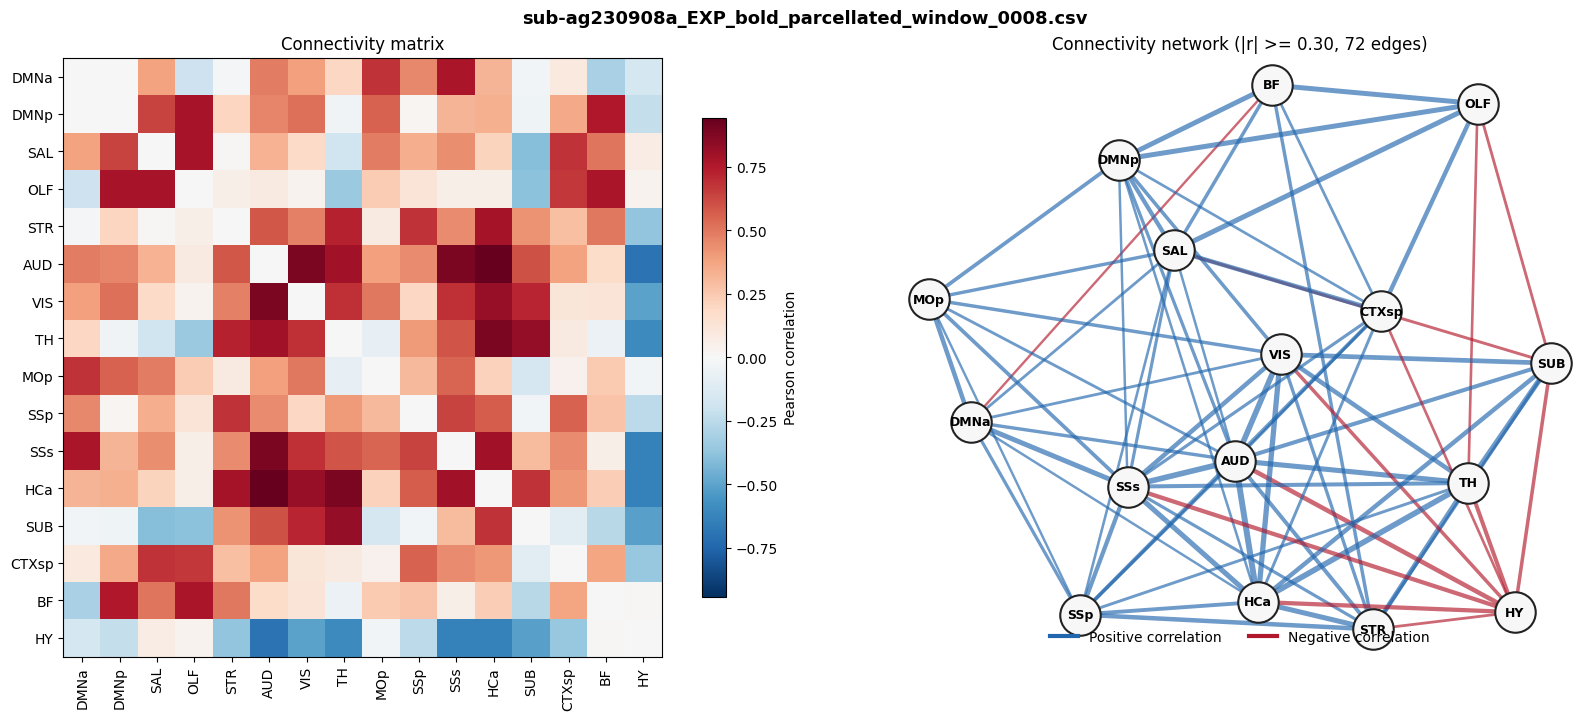

In [7]:
def build_connectivity_graph(connectivity_df):
    """Build a complete weighted graph from a connectivity matrix."""
    roi_names = list(connectivity_df.columns)
    graph = ig.Graph.Full(len(roi_names))
    graph.vs["name"] = roi_names
    graph.vs["id"] = roi_names

    corr_array = connectivity_df.to_numpy(dtype=float)
    row_indices, col_indices = np.triu_indices(len(roi_names), k=1)
    graph.es["weight"] = corr_array[row_indices, col_indices].tolist()
    return graph


def plot_connectivity_graph(connectivity_df, csv_path=None, threshold=0.3):
    """Plot the correlation matrix and its signed weighted network.

    The graph retains edges whose absolute correlation is at least threshold.
    Blue edges are positive, red edges are negative, and width is proportional
    to absolute correlation strength.
    """
    graph = build_connectivity_graph(connectivity_df)
    weights = np.asarray(graph.es["weight"], dtype=float)
    visible_edge_ids = np.flatnonzero(np.abs(weights) >= threshold).tolist()
    display_graph = graph.subgraph_edges(visible_edge_ids, delete_vertices=False)
    display_weights = np.asarray(display_graph.es["weight"], dtype=float)

    fig, (ax_matrix, ax_graph) = plt.subplots(1, 2, figsize=(17, 7))

    limit = max(abs(connectivity_df.to_numpy(dtype=float).min()),
                abs(connectivity_df.to_numpy(dtype=float).max()))
    image = ax_matrix.imshow(
        connectivity_df.to_numpy(dtype=float),
        cmap="RdBu_r",
        vmin=-limit,
        vmax=limit,
    )
    ax_matrix.set_xticks(range(len(connectivity_df.columns)), connectivity_df.columns,
                         rotation=90)
    ax_matrix.set_yticks(range(len(connectivity_df.index)), connectivity_df.index)
    ax_matrix.set_title("Connectivity matrix")
    fig.colorbar(image, ax=ax_matrix, shrink=0.8, label="Pearson correlation")

    layout = display_graph.layout("kk")
    coordinates = np.asarray(layout.coords)
    for edge, weight in zip(display_graph.es, display_weights):
        source, target = edge.tuple
        x = coordinates[[source, target], 0]
        y = coordinates[[source, target], 1]
        ax_graph.plot(
            x, y,
            color="#2166ac" if weight > 0 else "#b2182b",
            linewidth=0.5 + 4.0 * abs(weight),
            alpha=0.65,
            zorder=1,
        )

    ax_graph.scatter(
        coordinates[:, 0], coordinates[:, 1],
        s=850, color="#f7f7f7", edgecolor="#222222", linewidth=1.5, zorder=2,
    )
    for vertex, (x, y) in zip(display_graph.vs, coordinates):
        ax_graph.text(x, y, vertex["name"], ha="center", va="center",
                      fontsize=9, fontweight="bold", zorder=3)

    legend_items = [
        Line2D([0], [0], color="#2166ac", lw=3, label="Positive correlation"),
        Line2D([0], [0], color="#b2182b", lw=3, label="Negative correlation"),
    ]
    ax_graph.legend(handles=legend_items, loc="lower center", ncol=2, frameon=False)
    ax_graph.set_title(
        f"Connectivity network (|r| >= {threshold:.2f}, {display_graph.ecount()} edges)"
    )
    ax_graph.set_aspect("equal")
    ax_graph.axis("off")

    title = os.path.basename(csv_path) if csv_path else "Weighted functional connectivity"
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig, graph


fig, graph = plot_connectivity_graph(df, first_csv_path, threshold=0.3)
plt.show()

### Run Louvain Temporal Community Detection

In [8]:
def build_temporal_graphs(csv_paths):
    """Create one connectivity graph per CSV window in temporal order."""
    graphs = []
    expected_rois = None

    # Iterate over CSV paths, build a graph for each, and check 
    # that ROIs are consistent.
    for csv_path in csv_paths:
        connectivity_df = pd.read_csv(csv_path, index_col=0)
        roi_names = list(connectivity_df.columns)

        if expected_rois is None:
            expected_rois = roi_names
        elif roi_names != expected_rois:
            raise ValueError(f"ROI names or order differ in {csv_path}")

        graphs.append(build_connectivity_graph(connectivity_df))

    if len(graphs) < 2:
        raise ValueError("Temporal community detection requires at least two windows")

    return graphs


# Use all sorted windows belonging to the selected mouse.
mouse_windows = dta_anes_mice[first_date][first_mouse]
temporal_graphs = build_temporal_graphs(mouse_windows)

# Try different values of GAMMA to see how it affect number of communities

GAMMA_VALUES = np.arange(0.1, 0.9, 0.1)

memberships, improvement = la.find_partition_temporal(
        temporal_graphs,
        la.CPMVertexPartition,
        interslice_weight=OMEGA,
        vertex_id_attr="id",
        weight_attr="weight",
        resolution_parameter=GAMMA,
    )

membership_matrix = np.asarray(memberships, dtype=int)
print(f"Mouse: {first_mouse}")
# print(f"Windows: {len(temporal_graphs)}")
# print(f"Membership matrix: {membership_matrix.shape}")
print(f"Quality improvement: {improvement:.3f}")
print("\n")
# Count the number of unique communities in each time window (row).
communities_per_window = np.array([
    len(np.unique(row))
    for row in membership_matrix
])

print("GAMMA VALUE:", GAMMA)

print("Minimum:", communities_per_window.min())
print("Maximum:", communities_per_window.max())
print("Mean:", communities_per_window.mean())
print("Median:", np.median(communities_per_window))
print("\n")



""" for gamma in GAMMA_VALUES:
    # find_partition_temporal expects a list of graphs, one graph per time window.
    memberships, improvement = la.find_partition_temporal(
        temporal_graphs,
        la.CPMVertexPartition,
        interslice_weight=OMEGA,
        vertex_id_attr="id",
        weight_attr="weight",
        resolution_parameter=gamma,
    )

    membership_matrix = np.asarray(memberships, dtype=int)
    print(f"Mouse: {first_mouse}")
    # print(f"Windows: {len(temporal_graphs)}")
    # print(f"Membership matrix: {membership_matrix.shape}")
    print(f"Quality improvement: {improvement:.3f}")
    print("\n")
    # Count the number of unique communities in each time window (row).
    communities_per_window = np.array([
        len(np.unique(row))
        for row in membership_matrix
    ])

    communities_per_window

    print("Minimum:", communities_per_window.min())
    print("Maximum:", communities_per_window.max())
    print("Mean:", communities_per_window.mean())
    print("Median:", np.median(communities_per_window))
    print("\n")

 """

Mouse: sub-ag230908a
Quality improvement: 10384.000


GAMMA VALUE: 1
Minimum: 16
Maximum: 16
Mean: 16.0
Median: 16.0




' for gamma in GAMMA_VALUES:\n    # find_partition_temporal expects a list of graphs, one graph per time window.\n    memberships, improvement = la.find_partition_temporal(\n        temporal_graphs,\n        la.CPMVertexPartition,\n        interslice_weight=OMEGA,\n        vertex_id_attr="id",\n        weight_attr="weight",\n        resolution_parameter=gamma,\n    )\n\n    membership_matrix = np.asarray(memberships, dtype=int)\n    print(f"Mouse: {first_mouse}")\n    # print(f"Windows: {len(temporal_graphs)}")\n    # print(f"Membership matrix: {membership_matrix.shape}")\n    print(f"Quality improvement: {improvement:.3f}")\n    print("\n")\n    # Count the number of unique communities in each time window (row).\n    communities_per_window = np.array([\n        len(np.unique(row))\n        for row in membership_matrix\n    ])\n\n    communities_per_window\n\n    print("Minimum:", communities_per_window.min())\n    print("Maximum:", communities_per_window.max())\n    print("Mean:", com

### Display communities found by temporal Louvain

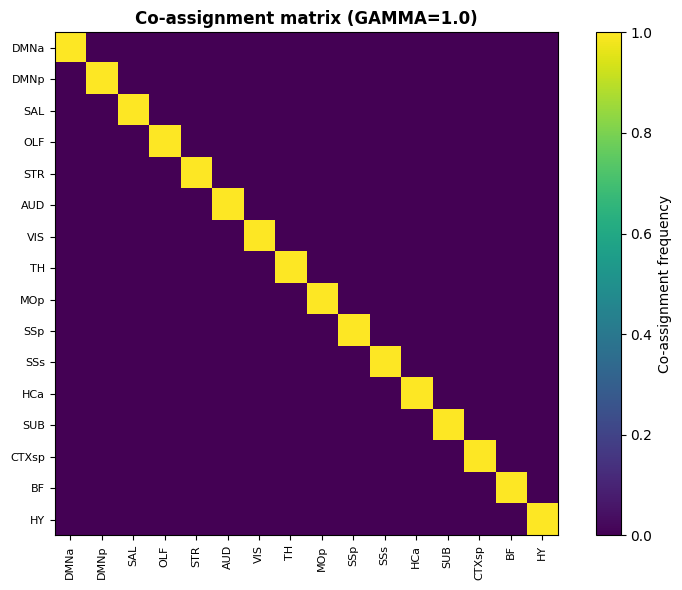

In [ ]:
# Compute the co-assignment matrix, which counts how many times each pair of ROIs is assigned to the same community across all time windows.
n_rois = membership_matrix.shape[1]
coassignment = np.zeros((n_rois, n_rois), dtype=float)

# For each time window (row in membership_matrix), we compare the community assignments of all pairs of ROIs.
for row in membership_matrix:
    coassignment += row[:, None] == row[None, :]

coassignment /= len(membership_matrix)

coassignment_df = pd.DataFrame(
    coassignment,
    index=df.columns,
    columns=df.columns,
)

plt.figure(figsize=(8, 6))

image = plt.imshow(
    coassignment_df.to_numpy(),
    cmap="viridis",
    vmin=0,
    vmax=1,
)

plt.colorbar(image, label="Co-assignment frequency")
plt.xticks(
    range(len(coassignment_df.columns)),
    coassignment_df.columns,
    rotation=90,
    fontsize=8,
)
plt.yticks(
    range(len(coassignment_df.index)),
    coassignment_df.index,
    fontsize=8,
)

plt.title(
    f"Co-assignment matrix (GAMMA={GAMMA:.1f})",
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

In [10]:
# Count the number of unique communities in each time window (row).
communities_per_window = np.array([
    len(np.unique(row))
    for row in membership_matrix
])

communities_per_window

print("Minimum:", communities_per_window.min())
print("Maximum:", communities_per_window.max())
print("Mean:", communities_per_window.mean())
print("Median:", np.median(communities_per_window))

Minimum: 16
Maximum: 16
Mean: 16.0
Median: 16.0


In [11]:
community_counts = pd.DataFrame({
    "window": range(len(membership_matrix)),
    "n_communities": communities_per_window,
})

community_counts.head()

,window,n_communities
0,0,16
1,1,16
2,2,16
3,3,16
4,4,16
